# NCA GEDI L2A → L1B Spatial Subset Diagnostic

This notebook evaluates **spatial-only** subsetting of paired GEDI L2A and L1B data for the NCA.

There is **no GEDI quality filtering** in this workflow.

The logic is:

1. Start from a known NCA GEDI L1B granule.
2. Discover its matching L2A granule using the shared orbit/sub-orbit identifiers in the filenames.
3. Read shot locations from L2A.
4. Keep every L2A shot whose nominal shot location falls within the NCA polygon.
5. Match those retained `shot_number` values back to L1B by beam.
6. Measure:
   - L2A shots retained,
   - corresponding L1B shots retained,
   - RX waveform samples retained,
   - approximate waveform-storage reduction.
7. Build retained-shot lookup tables for later repacking.

The source HDF5 files are opened **read-only** and are not modified.

## Why L2A is the spatial index

L2A provides a convenient shot-oriented representation with geolocation. We therefore use L2A to define the set

\[
S_{AOI} = \{s_i : (x_i,y_i) \in AOI\}
\]

and then identify the corresponding L1B waveform payload using `shot_number`.

No assumption is made here that a shot is scientifically "good" or "bad." The only criterion is whether it lies spatially inside the NCA.


In [3]:
from pathlib import Path
import re

import h5py
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)


## 1. Paths

The known NCA L1B granule is already populated.

Only `aoi_path` needs to be replaced with the actual NCA shapefile path.

The notebook assumes the NCA GEDI directory is organized as:

```text
A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\raw_h5\
    GEDI01_B\
    GEDI02_A\
```

If the L2A directory differs, change `l2a_dir`.


In [4]:
l1b_path = Path(
    r"A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\raw_h5\GEDI01_B"
    r"\GEDI01_B_2019292203447_O04828_03_T03479_02_005_01_V002.h5"
)

l2a_dir = Path(
    r"A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\raw_h5\GEDI02_A"
)

# SUPPLY THIS PATH:
aoi_path = Path(
    r"A:\NCA_DATA\templates\NCA_NAD83UTM11N.shp"
)

print("L1B:", l1b_path)
print("L2A directory:", l2a_dir)
print("AOI:", aoi_path)

assert l1b_path.exists(), f"L1B file not found:\n{l1b_path}"
assert l2a_dir.exists(), f"L2A directory not found:\n{l2a_dir}"
assert aoi_path.exists(), f"AOI file not found:\n{aoi_path}"


L1B: A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\raw_h5\GEDI01_B\GEDI01_B_2019292203447_O04828_03_T03479_02_005_01_V002.h5
L2A directory: A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\raw_h5\GEDI02_A
AOI: A:\NCA_DATA\templates\NCA_NAD83UTM11N.shp


## 2. Discover the matching L2A granule

GEDI L1B and L2A filenames are not identical, but corresponding granules share orbital identifiers such as:

```text
O04828_03_T03479_02
```

This cell extracts that identifier from the known L1B filename and searches the NCA L2A directory for a unique match.

If more than one candidate is found, the notebook stops rather than silently choosing one.


In [5]:
def extract_granule_key(filename):
    """
    Extract the shared GEDI orbit/sub-orbit key:
    O#####_##_T#####_##
    """
    match = re.search(r"(O\d{5}_\d{2}_T\d{5}_\d{2})", filename)
    if match is None:
        raise ValueError(
            f"Could not extract orbit key from filename:\n{filename}"
        )
    return match.group(1)


granule_key = extract_granule_key(l1b_path.name)

l2a_candidates = sorted(
    p for p in l2a_dir.glob("*.h5")
    if granule_key in p.name
)

print("Granule key:", granule_key)
print(f"L2A candidates found: {len(l2a_candidates)}")

for candidate in l2a_candidates:
    print(" ", candidate.name)

if len(l2a_candidates) == 0:
    raise FileNotFoundError(
        f"No L2A file containing {granule_key} was found in:\n{l2a_dir}"
    )

if len(l2a_candidates) > 1:
    raise RuntimeError(
        "More than one L2A candidate matched. "
        "Inspect the candidates before continuing."
    )

l2a_path = l2a_candidates[0]

print("\nMatched pair")
print("------------")
print("L1B:", l1b_path.name)
print("L2A:", l2a_path.name)


Granule key: O04828_03_T03479_02
L2A candidates found: 1
  GEDI02_A_2019292203447_O04828_03_T03479_02_003_01_V002.h5

Matched pair
------------
L1B: GEDI01_B_2019292203447_O04828_03_T03479_02_005_01_V002.h5
L2A: GEDI02_A_2019292203447_O04828_03_T03479_02_003_01_V002.h5


## 3. Read the NCA polygon

GEDI shot coordinates are longitude/latitude, so the AOI is transformed to EPSG:4326 before the point-in-polygon operation.

Multiple AOI features are merged into one geometry.


In [6]:
aoi = gpd.read_file(aoi_path)

print("Original CRS:", aoi.crs)
print("Feature count:", len(aoi))

if aoi.crs is None:
    raise ValueError(
        "The AOI has no defined CRS. Its correct CRS must be assigned "
        "before spatial filtering."
    )

aoi_4326 = aoi.to_crs("EPSG:4326")
aoi_geom = aoi_4326.geometry.union_all()

print("Analysis CRS: EPSG:4326")
print("AOI bounds:")
print(np.round(aoi_4326.total_bounds, 6))


Original CRS: EPSG:26911
Feature count: 1
Analysis CRS: EPSG:4326
AOI bounds:
[-116.658145   42.776977 -115.380147   43.489765]


## 4. Inspect L2A beam structure and coordinate fields

The notebook prefers shot-level L2A coordinate datasets in this order:

1. `lat_lowestmode` / `lon_lowestmode`
2. `geolocation/latitude_lowestmode` / `geolocation/longitude_lowestmode`
3. `lat_highestreturn` / `lon_highestreturn` as a fallback

The chosen coordinate source is reported explicitly for every beam.

For AOI membership this is a **nominal shot-position test**, not a footprint-overlap test.


In [7]:
def discover_beams(h5):
    return sorted(
        key for key in h5.keys()
        if key.startswith("BEAM")
    )


def get_l2a_coordinate_paths(h5, beam):
    """
    Return an available L2A coordinate pair.
    """
    candidate_pairs = [
        (
            f"{beam}/lat_lowestmode",
            f"{beam}/lon_lowestmode",
            "lat/lon_lowestmode",
        ),
        (
            f"{beam}/geolocation/latitude_lowestmode",
            f"{beam}/geolocation/longitude_lowestmode",
            "geolocation lowestmode",
        ),
        (
            f"{beam}/lat_highestreturn",
            f"{beam}/lon_highestreturn",
            "lat/lon_highestreturn",
        ),
    ]

    for lat_path, lon_path, label in candidate_pairs:
        if lat_path in h5 and lon_path in h5:
            return lat_path, lon_path, label

    raise KeyError(
        f"No supported L2A shot-coordinate pair found for {beam}"
    )


with h5py.File(l2a_path, "r") as h5:
    l2a_beams = discover_beams(h5)

    print(f"L2A beams: {len(l2a_beams)}")
    print(l2a_beams)

    for beam in l2a_beams:
        try:
            lat_path, lon_path, label = get_l2a_coordinate_paths(h5, beam)
            print(f"{beam}: {label}")
        except KeyError as exc:
            print(f"{beam}: {exc}")


L2A beams: 8
['BEAM0000', 'BEAM0001', 'BEAM0010', 'BEAM0011', 'BEAM0101', 'BEAM0110', 'BEAM1000', 'BEAM1011']
BEAM0000: lat/lon_lowestmode
BEAM0001: lat/lon_lowestmode
BEAM0010: lat/lon_lowestmode
BEAM0011: lat/lon_lowestmode
BEAM0101: lat/lon_lowestmode
BEAM0110: lat/lon_lowestmode
BEAM1000: lat/lon_lowestmode
BEAM1011: lat/lon_lowestmode


## 5. Spatially subset L2A shots

Every shot with a finite coordinate is tested against the NCA polygon.

**No quality flags are read or applied.**

The output `l2a_retained` contains the complete set of L2A shot identifiers selected solely by spatial membership.


In [8]:
# ------------------------------------------------------------
# 5. Loop through all L2A granules and spatially retain NCA shots
# ------------------------------------------------------------

l2a_files = sorted(l2a_dir.glob("*.h5"))

print(f"L2A granules found: {len(l2a_files):,}")

all_l2a_records = []
granule_spatial_summary = []

for file_i, current_l2a_path in enumerate(l2a_files, start=1):

    print(
        f"\n[{file_i}/{len(l2a_files)}] "
        f"{current_l2a_path.name}"
    )

    try:
        granule_key = extract_granule_key(current_l2a_path.name)
    except ValueError as exc:
        print(f"  SKIP: {exc}")
        continue

    file_records = []

    total_file_shots = 0
    valid_file_coords = 0
    inside_file_shots = 0

    with h5py.File(current_l2a_path, "r") as h5:

        beams = discover_beams(h5)

        for beam in beams:

            shot_path = f"{beam}/shot_number"

            if shot_path not in h5:
                print(f"  {beam}: missing shot_number")
                continue

            try:
                lat_path, lon_path, coord_source = (
                    get_l2a_coordinate_paths(h5, beam)
                )
            except KeyError:
                print(f"  {beam}: no supported coordinate pair")
                continue

            shot = h5[shot_path][:]
            lat = h5[lat_path][:]
            lon = h5[lon_path][:]

            if not (len(shot) == len(lat) == len(lon)):
                raise ValueError(
                    f"Length mismatch in {current_l2a_path.name}, {beam}: "
                    f"shot={len(shot)}, "
                    f"lat={len(lat)}, "
                    f"lon={len(lon)}"
                )

            valid_xy = (
                np.isfinite(lat)
                & np.isfinite(lon)
                & (lat >= -90)
                & (lat <= 90)
                & (lon >= -180)
                & (lon <= 180)
            )

            inside = np.zeros(len(shot), dtype=bool)

            if valid_xy.any():

                # Compatible with older Shapely versions
                geoms = [
                    Point(x, y)
                    for x, y in zip(
                        lon[valid_xy],
                        lat[valid_xy]
                    )
                ]

                spatial_result = np.asarray(
                    gpd.GeoSeries(
                        geoms,
                        crs="EPSG:4326"
                    ).within(aoi_geom)
                )

                inside[np.flatnonzero(valid_xy)] = spatial_result

            n_total = len(shot)
            n_valid = int(valid_xy.sum())
            n_inside = int(inside.sum())

            total_file_shots += n_total
            valid_file_coords += n_valid
            inside_file_shots += n_inside

            if n_inside > 0:

                print(
                    f"  {beam}: "
                    f"{n_inside:,} / {n_total:,} inside NCA"
                )

                file_records.append(
                    pd.DataFrame(
                        {
                            "source_l2a": current_l2a_path.name,
                            "granule_key": granule_key,
                            "beam": beam,
                            "shot_number": shot[inside],
                            "longitude": lon[inside],
                            "latitude": lat[inside],
                        }
                    )
                )

    # Combine all retained shots from this granule
    if file_records:

        retained_this_file = pd.concat(
            file_records,
            ignore_index=True
        )

        all_l2a_records.append(retained_this_file)

        print(
            f"  RETAIN: {inside_file_shots:,} NCA shots"
        )

    else:
        print("  No NCA shots")

    granule_spatial_summary.append(
        {
            "source_l2a": current_l2a_path.name,
            "granule_key": granule_key,
            "total_l2a_shots": total_file_shots,
            "valid_coordinates": valid_file_coords,
            "nca_shots": inside_file_shots,
            "nca_shot_percent": (
                100 * inside_file_shots / total_file_shots
                if total_file_shots > 0
                else np.nan
            ),
        }
    )


# ------------------------------------------------------------
# Combine collection-wide results
# ------------------------------------------------------------

granule_spatial_summary = pd.DataFrame(
    granule_spatial_summary
)

if all_l2a_records:
    l2a_retained = pd.concat(
        all_l2a_records,
        ignore_index=True
    )
else:
    l2a_retained = pd.DataFrame(
        columns=[
            "source_l2a",
            "granule_key",
            "beam",
            "shot_number",
            "longitude",
            "latitude",
        ]
    )


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

n_intersecting = int(
    (granule_spatial_summary["nca_shots"] > 0).sum()
)

print("\n====================================")
print("NCA L2A SPATIAL FILTER COMPLETE")
print("====================================")

print(f"Total L2A granules:       {len(l2a_files):,}")
print(f"Intersecting granules:    {n_intersecting:,}")
print(
    f"Non-intersecting:         "
    f"{len(l2a_files) - n_intersecting:,}"
)
print(f"Total retained NCA shots: {len(l2a_retained):,}")

display(
    granule_spatial_summary.sort_values(
        "nca_shots",
        ascending=False
    )
)

display(l2a_retained.head(20))

L2A granules found: 318

[1/318] GEDI02_A_2019109210809_O01988_03_T02056_02_003_01_V002.h5
  No NCA shots

[2/318] GEDI02_A_2019114135421_O02061_02_T00905_02_003_01_V002.h5
  BEAM0000: 870 / 106,684 inside NCA
  BEAM0001: 863 / 105,708 inside NCA
  BEAM0010: 859 / 106,718 inside NCA
  BEAM0011: 852 / 105,719 inside NCA
  BEAM0101: 849 / 105,551 inside NCA
  BEAM0110: 861 / 115,566 inside NCA
  BEAM1000: 863 / 106,896 inside NCA
  BEAM1011: 869 / 105,434 inside NCA
  RETAIN: 6,886 NCA shots

[3/318] GEDI02_A_2019116182542_O02095_03_T01903_02_003_01_V002.h5
  No NCA shots

[4/318] GEDI02_A_2019121111147_O02168_02_T05021_02_003_01_V002.h5
  BEAM0000: 820 / 106,043 inside NCA
  BEAM0001: 801 / 105,203 inside NCA
  BEAM0010: 786 / 106,066 inside NCA
  BEAM0011: 763 / 105,218 inside NCA
  BEAM0101: 694 / 105,046 inside NCA
  BEAM0110: 677 / 114,984 inside NCA
  BEAM1000: 679 / 106,219 inside NCA
  BEAM1011: 678 / 104,954 inside NCA
  RETAIN: 5,898 NCA shots

[5/318] GEDI02_A_2019123154305_O0

,source_l2a,granule_key,total_l2a_shots,valid_coordinates,nca_shots,nca_shot_percent
257,GEDI02_A_2022357172031_O22826_03_T05713_02_003...,O22826_03_T05713_02,1293697,1293697,15096,1.166888
242,GEDI02_A_2022288203631_O21758_03_T00021_02_003...,O21758_03_T00021_02,1298202,1298202,15051,1.159373
178,GEDI02_A_2022025045934_O17669_03_T05713_02_003...,O17669_03_T05713_02,1297289,1297289,15034,1.158878
42,GEDI02_A_2019288221209_O04767_03_T00021_02_003...,O04767_03_T00021_02,1298346,1298346,15015,1.156471
198,GEDI02_A_2022109193010_O18981_03_T07136_02_003...,O18981_03_T07136_02,1297480,1297480,14977,1.154315
...,...,...,...,...,...,...
10,GEDI02_A_2019144073502_O02523_03_T02408_02_003...,O02523_03_T02408_02,1293281,1293281,0,0.000000
314,GEDI02_A_2024325051541_O33644_03_T10640_02_004...,O33644_03_T10640_02,1272103,1272103,0,0.000000
315,GEDI02_A_2024329033947_O33705_03_T09217_02_004...,O33705_03_T09217_02,1281543,1281543,0,0.000000
2,GEDI02_A_2019116182542_O02095_03_T01903_02_003...,O02095_03_T01903_02,1312167,1312167,0,0.000000


,source_l2a,granule_key,beam,shot_number,longitude,latitude
0,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092326,-116.036588,42.919770
1,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092327,-116.036008,42.920057
2,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092328,-116.035427,42.920344
3,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092329,-116.034847,42.920631
4,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092330,-116.034266,42.920918
5,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092331,-116.033685,42.921205
6,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092332,-116.033105,42.921491
7,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092333,-116.032524,42.921778
8,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092334,-116.031943,42.922065
9,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092335,-116.031363,42.922352


In [9]:
# ------------------------------------------------------------
# 6. Match spatially retained L2A shots to L1B
# ------------------------------------------------------------

l1b_dir = l1b_path.parent

l1b_files = sorted(l1b_dir.glob("*.h5"))

print(f"L1B granules found: {len(l1b_files):,}")


# ------------------------------------------------------------
# Build a lookup from granule key -> L1B file
# ------------------------------------------------------------

l1b_lookup = {}

for path in l1b_files:

    try:
        key = extract_granule_key(path.name)
    except ValueError:
        continue

    if key in l1b_lookup:
        print(
            f"WARNING: duplicate L1B granule key {key}"
        )

    l1b_lookup[key] = path


# ------------------------------------------------------------
# Only process granules that actually intersect the NCA
# ------------------------------------------------------------

intersecting_granules = (
    granule_spatial_summary.loc[
        granule_spatial_summary["nca_shots"] > 0
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    f"\nIntersecting L2A granules to match: "
    f"{len(intersecting_granules):,}"
)


all_l1b_records = []
l1b_granule_summary = []


for row_i, row in intersecting_granules.iterrows():

    granule_key = row["granule_key"]
    source_l2a = row["source_l2a"]

    print(
        f"\n[{row_i + 1}/{len(intersecting_granules)}] "
        f"{granule_key}"
    )

    # --------------------------------------------------------
    # Find paired L1B
    # --------------------------------------------------------

    current_l1b_path = l1b_lookup.get(granule_key)

    if current_l1b_path is None:

        print("  ERROR: matching L1B not found")

        l1b_granule_summary.append(
            {
                "granule_key": granule_key,
                "source_l2a": source_l2a,
                "source_l1b": None,
                "matching_l1b_found": False,
                "l2a_nca_shots": int(row["nca_shots"]),
                "matched_l1b_shots": 0,
                "total_l1b_shots": np.nan,
                "total_rx_samples": np.nan,
                "retained_rx_samples": np.nan,
                "rx_retained_percent": np.nan,
                "l1b_file_size_gib": np.nan,
            }
        )

        continue

    print(f"  L1B: {current_l1b_path.name}")

    # L2A-selected shots for this granule
    selected = l2a_retained.loc[
        l2a_retained["granule_key"].eq(granule_key)
    ].copy()

    file_match_records = []

    total_l1b_shots = 0
    matched_l1b_shots = 0

    total_rx_samples = 0
    retained_rx_samples = 0


    # --------------------------------------------------------
    # Open paired L1B
    # --------------------------------------------------------

    with h5py.File(current_l1b_path, "r") as h5:

        beams = discover_beams(h5)

        for beam in beams:

            shot_path = f"{beam}/shot_number"
            count_path = f"{beam}/rx_sample_count"
            start_path = f"{beam}/rx_sample_start_index"

            if shot_path not in h5:
                continue

            l1b_shot = h5[shot_path][:]

            total_l1b_shots += len(l1b_shot)

            target = selected.loc[
                selected["beam"].eq(beam),
                "shot_number"
            ].to_numpy()

            if len(target) == 0:
                continue

            mask = np.isin(
                l1b_shot,
                target
            )

            n_matched = int(mask.sum())

            matched_l1b_shots += n_matched

            print(
                f"  {beam}: "
                f"{n_matched:,} / {len(target):,} "
                f"selected shots matched"
            )

            # ------------------------------------------------
            # Waveform accounting
            # ------------------------------------------------

            if (
                count_path not in h5
                or start_path not in h5
            ):
                print(
                    f"    WARNING: waveform indexing missing"
                )
                continue

            sample_count = h5[count_path][:]
            sample_start = h5[start_path][:]

            if len(sample_count) != len(l1b_shot):
                raise ValueError(
                    f"{current_l1b_path.name}, {beam}: "
                    "rx_sample_count length does not match "
                    "shot_number"
                )

            total_rx_samples += int(
                sample_count.sum()
            )

            retained_rx_samples += int(
                sample_count[mask].sum()
            )

            if n_matched > 0:

                file_match_records.append(
                    pd.DataFrame(
                        {
                            "source_l1b":
                                current_l1b_path.name,
                            "source_l2a":
                                source_l2a,
                            "granule_key":
                                granule_key,
                            "beam":
                                beam,
                            "shot_number":
                                l1b_shot[mask],
                            "rx_sample_start_index":
                                sample_start[mask],
                            "rx_sample_count":
                                sample_count[mask],
                        }
                    )
                )


    # --------------------------------------------------------
    # Keep matched-shot records
    # --------------------------------------------------------

    if file_match_records:

        matched_this_file = pd.concat(
            file_match_records,
            ignore_index=True
        )

        all_l1b_records.append(
            matched_this_file
        )


    rx_retained_percent = (
        100 * retained_rx_samples / total_rx_samples
        if total_rx_samples > 0
        else np.nan
    )


    l1b_granule_summary.append(
        {
            "granule_key": granule_key,
            "source_l2a": source_l2a,
            "source_l1b": current_l1b_path.name,
            "matching_l1b_found": True,
            "l2a_nca_shots": int(row["nca_shots"]),
            "matched_l1b_shots": matched_l1b_shots,
            "total_l1b_shots": total_l1b_shots,
            "total_rx_samples": total_rx_samples,
            "retained_rx_samples": retained_rx_samples,
            "rx_retained_percent": rx_retained_percent,
            "l1b_file_size_gib": (
                current_l1b_path.stat().st_size
                / 1024**3
            ),
        }
    )

    print(
        f"  RX waveform retained: "
        f"{rx_retained_percent:.4f}%"
    )


# ------------------------------------------------------------
# Combine collection-wide L1B results
# ------------------------------------------------------------

l1b_granule_summary = pd.DataFrame(
    l1b_granule_summary
)

if all_l1b_records:

    l1b_retained = pd.concat(
        all_l1b_records,
        ignore_index=True
    )

else:

    l1b_retained = pd.DataFrame(
        columns=[
            "source_l1b",
            "source_l2a",
            "granule_key",
            "beam",
            "shot_number",
            "rx_sample_start_index",
            "rx_sample_count",
        ]
    )


# ------------------------------------------------------------
# Pairing integrity
# ------------------------------------------------------------

selected_keys = set(
    zip(
        l2a_retained["granule_key"].astype(str),
        l2a_retained["beam"].astype(str),
        l2a_retained["shot_number"].astype(np.uint64),
    )
)

matched_keys = set(
    zip(
        l1b_retained["granule_key"].astype(str),
        l1b_retained["beam"].astype(str),
        l1b_retained["shot_number"].astype(np.uint64),
    )
)

unmatched_keys = selected_keys - matched_keys


# ------------------------------------------------------------
# Collection-wide summary
# ------------------------------------------------------------

total_retained_rx = (
    l1b_granule_summary["retained_rx_samples"]
    .fillna(0)
    .sum()
)

total_intersecting_rx = (
    l1b_granule_summary["total_rx_samples"]
    .fillna(0)
    .sum()
)

overall_rx_retention = (
    100 * total_retained_rx / total_intersecting_rx
    if total_intersecting_rx > 0
    else np.nan
)

print("\n====================================")
print("NCA L1B / L2A MATCHING COMPLETE")
print("====================================")

print(
    f"Spatially retained L2A shots: "
    f"{len(l2a_retained):,}"
)

print(
    f"Matched L1B shots:            "
    f"{len(l1b_retained):,}"
)

print(
    f"Unmatched L2A shots:          "
    f"{len(unmatched_keys):,}"
)

print(
    f"RX samples retained:          "
    f"{int(total_retained_rx):,}"
)

print(
    f"Overall RX retention*:        "
    f"{overall_rx_retention:.4f}%"
)

print(
    "\n*Among L1B granules whose paired L2A granule "
    "actually intersects the NCA."
)

display(
    l1b_granule_summary.sort_values(
        "rx_retained_percent",
        ascending=False
    )
)

display(l1b_retained.head(20))

L1B granules found: 316

Intersecting L2A granules to match: 189

[1/189] O02061_02_T00905_02
  L1B: GEDI01_B_2019114135421_O02061_02_T00905_02_005_01_V002.h5
  BEAM0000: 870 / 870 selected shots matched
  BEAM0001: 863 / 863 selected shots matched
  BEAM0010: 859 / 859 selected shots matched
  BEAM0011: 852 / 852 selected shots matched
  BEAM0101: 849 / 849 selected shots matched
  BEAM0110: 861 / 861 selected shots matched
  BEAM1000: 863 / 863 selected shots matched
  BEAM1011: 869 / 869 selected shots matched
  RX waveform retained: 0.8010%

[2/189] O02168_02_T05021_02
  L1B: GEDI01_B_2019121111147_O02168_02_T05021_02_005_01_V002.h5
  BEAM0000: 820 / 820 selected shots matched
  BEAM0001: 801 / 801 selected shots matched
  BEAM0010: 786 / 786 selected shots matched
  BEAM0011: 763 / 763 selected shots matched
  BEAM0101: 694 / 694 selected shots matched
  BEAM0110: 677 / 677 selected shots matched
  BEAM1000: 679 / 679 selected shots matched
  BEAM1011: 678 / 678 selected shots mat

,granule_key,source_l2a,source_l1b,matching_l1b_found,l2a_nca_shots,matched_l1b_shots,total_l1b_shots,total_rx_samples,retained_rx_samples,rx_retained_percent,l1b_file_size_gib
34,O05530_03_T05560_02,GEDI02_A_2019338024502_O05530_03_T05560_02_003...,GEDI01_B_2019338024502_O05530_03_T05560_02_005...,True,14865,14865,1300812,900470839,15345815,1.704199,3.459582
164,O30726_02_T08173_02,GEDI02_A_2024137021254_O30726_02_T08173_02_004...,GEDI01_B_2024137021254_O30726_02_T08173_02_006...,True,2302,2302,242445,102349450,1717785,1.678353,0.536269
25,O04355_03_T04290_02,GEDI02_A_2019262084455_O04355_03_T04290_02_003...,GEDI01_B_2019262084455_O04355_03_T04290_02_005...,True,14837,14837,1299704,858166086,12858408,1.498359,3.325941
105,O17669_03_T05713_02,GEDI02_A_2022025045934_O17669_03_T05713_02_003...,GEDI01_B_2022025045934_O17669_03_T05713_02_005...,True,15034,15034,1297289,862564929,12319158,1.428201,3.347023
117,O18981_03_T07136_02,GEDI02_A_2022109193010_O18981_03_T07136_02_003...,GEDI01_B_2022109193010_O18981_03_T07136_02_005...,True,14977,14977,1297480,820281376,11222907,1.368178,3.236395
...,...,...,...,...,...,...,...,...,...,...,...
79,O15214_03_T00327_02,GEDI02_A_2021231193635_O15214_03_T00327_02_003...,GEDI01_B_2021231193635_O15214_03_T00327_02_005...,True,150,150,1296909,211806089,128449,0.060645,3.290024
51,O11734_02_T06949_02,GEDI02_A_2021007070555_O11734_02_T06949_02_003...,GEDI01_B_2021007070555_O11734_02_T06949_02_005...,True,42,42,1338731,73230290,35233,0.048113,2.483273
98,O17330_02_T06949_02,GEDI02_A_2022003081947_O17330_02_T06949_02_003...,GEDI01_B_2022003081947_O17330_02_T06949_02_005...,True,41,41,1338200,68429971,31254,0.045673,2.436152
78,O15153_03_T00327_02,GEDI02_A_2021227210902_O15153_03_T00327_02_003...,GEDI01_B_2021227210902_O15153_03_T00327_02_005...,True,9,9,1301203,106828461,6970,0.006524,3.295906


,source_l1b,source_l2a,granule_key,beam,shot_number,rx_sample_start_index,rx_sample_count
0,GEDI01_B_2019114135421_O02061_02_T00905_02_005...,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092326,71842061,741
1,GEDI01_B_2019114135421_O02061_02_T00905_02_005...,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092327,71843481,737
2,GEDI01_B_2019114135421_O02061_02_T00905_02_005...,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092328,71844901,751
3,GEDI01_B_2019114135421_O02061_02_T00905_02_005...,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092329,71846321,741
4,GEDI01_B_2019114135421_O02061_02_T00905_02_005...,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092330,71847741,742
5,GEDI01_B_2019114135421_O02061_02_T00905_02_005...,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092331,71849161,747
6,GEDI01_B_2019114135421_O02061_02_T00905_02_005...,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092332,71850581,740
7,GEDI01_B_2019114135421_O02061_02_T00905_02_005...,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092333,71852001,741
8,GEDI01_B_2019114135421_O02061_02_T00905_02_005...,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092334,71853421,741
9,GEDI01_B_2019114135421_O02061_02_T00905_02_005...,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,O02061_02_T00905_02,BEAM0000,20610000200092335,71854841,736


## 7. Pair integrity check

For a clean L2A → L1B subset workflow, every spatially retained L2A shot should ideally have a corresponding L1B shot in the paired granule.

This cell reports any unmatched shot IDs explicitly rather than assuming the products are perfectly paired.


In [10]:
selected_keys = set(
    zip(
        l2a_retained["beam"].astype(str),
        l2a_retained["shot_number"].astype(np.uint64),
    )
)

matched_keys = set(
    zip(
        l1b_retained["beam"].astype(str),
        l1b_retained["shot_number"].astype(np.uint64),
    )
)

unmatched_keys = selected_keys - matched_keys

print(f"L2A spatial selections: {len(selected_keys):,}")
print(f"L1B matches:            {len(matched_keys):,}")
print(f"Unmatched L2A shots:    {len(unmatched_keys):,}")

if unmatched_keys:
    unmatched = pd.DataFrame(
        sorted(unmatched_keys),
        columns=["beam", "shot_number"]
    )
    display(unmatched.head(50))
else:
    print("All spatially selected L2A shots matched L1B.")


L2A spatial selections: 1,319,778
L1B matches:            1,319,778
Unmatched L2A shots:    0
All spatially selected L2A shots matched L1B.


In [11]:
# ------------------------------------------------------------
# 8. Collection-wide summary
# ------------------------------------------------------------

n_l2a_granules = len(granule_spatial_summary)

n_intersecting = int(
    (granule_spatial_summary["nca_shots"] > 0).sum()
)

n_nonintersecting = n_l2a_granules - n_intersecting

total_nca_l2a_shots = len(l2a_retained)
total_matched_l1b_shots = len(l1b_retained)

n_l1b_found = int(
    l1b_granule_summary["matching_l1b_found"]
    .fillna(False)
    .sum()
)

total_rx_samples = int(
    pd.to_numeric(
        l1b_granule_summary["total_rx_samples"],
        errors="coerce"
    )
    .fillna(0)
    .sum()
)

retained_rx_samples = int(
    pd.to_numeric(
        l1b_granule_summary["retained_rx_samples"],
        errors="coerce"
    )
    .fillna(0)
    .sum()
)

rx_retained_percent = (
    100 * retained_rx_samples / total_rx_samples
    if total_rx_samples > 0
    else np.nan
)

pairing_complete = (
    len(unmatched_keys) == 0
    and total_nca_l2a_shots == total_matched_l1b_shots
)

collection_summary = pd.DataFrame(
    {
        "metric": [
            "L2A granules scanned",
            "L2A granules intersecting NCA",
            "L2A granules not intersecting NCA",
            "Intersecting granules with matching L1B",
            "Spatially retained L2A shots",
            "Matched L1B shots",
            "Unmatched L2A shots",
            "RX samples in intersecting L1B granules",
            "RX samples retained for NCA",
            "RX samples retained (%)",
        ],
        "value": [
            n_l2a_granules,
            n_intersecting,
            n_nonintersecting,
            n_l1b_found,
            total_nca_l2a_shots,
            total_matched_l1b_shots,
            len(unmatched_keys),
            total_rx_samples,
            retained_rx_samples,
            rx_retained_percent,
        ],
    }
)

display(collection_summary)

print("\nPAIRING CHECK")
print("-------------")
print(f"Exact L2A -> L1B correspondence: {pairing_complete}")

if pairing_complete:
    print(
        f"All {total_nca_l2a_shots:,} retained L2A shots "
        "have matching L1B shots."
    )
else:
    print(
        f"WARNING: {len(unmatched_keys):,} retained L2A shots "
        "do not have matching L1B records."
    )

print("\nWAVEFORM RETENTION")
print("------------------")
print(
    f"Retained RX samples: "
    f"{retained_rx_samples:,} / {total_rx_samples:,} "
    f"({rx_retained_percent:.4f}%)"
)

print(
    "\nNote: this RX denominator includes only L1B granules "
    "whose paired L2A granule intersects the NCA."
)

,metric,value
0,L2A granules scanned,3.180000e+02
1,L2A granules intersecting NCA,1.890000e+02
2,L2A granules not intersecting NCA,1.290000e+02
3,Intersecting granules with matching L1B,1.890000e+02
4,Spatially retained L2A shots,1.319778e+06
5,Matched L1B shots,1.319778e+06
6,Unmatched L2A shots,0.000000e+00
7,RX samples in intersecting L1B granules,1.126802e+11
8,RX samples retained for NCA,1.005082e+09
9,RX samples retained (%),8.919781e-01



PAIRING CHECK
-------------
Exact L2A -> L1B correspondence: True
All 1,319,778 retained L2A shots have matching L1B shots.

WAVEFORM RETENTION
------------------
Retained RX samples: 1,005,082,482 / 112,680,177,984 (0.8920%)

Note: this RX denominator includes only L1B granules whose paired L2A granule intersects the NCA.


SPATIAL QA
----------
Retained shots:          1,319,778
Inside AOI on recheck:   1,319,778
Outside AOI on recheck:  0


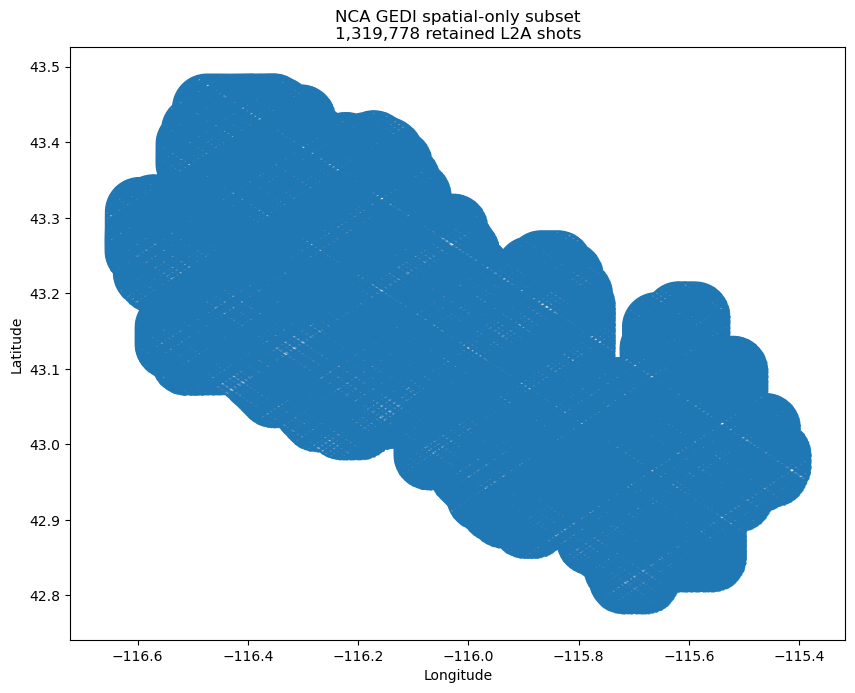

In [12]:
# ------------------------------------------------------------
# 9. Spatial QA
# ------------------------------------------------------------

retained_gdf = gpd.GeoDataFrame(
    l2a_retained.copy(),
    geometry=gpd.points_from_xy(
        l2a_retained["longitude"],
        l2a_retained["latitude"]
    ),
    crs="EPSG:4326",
)

# Independent re-check of the spatial criterion
qa_inside = retained_gdf.geometry.within(aoi_geom)

print("SPATIAL QA")
print("----------")
print(f"Retained shots:          {len(retained_gdf):,}")
print(f"Inside AOI on recheck:   {int(qa_inside.sum()):,}")
print(f"Outside AOI on recheck:  {int((~qa_inside).sum()):,}")

if not qa_inside.all():
    raise ValueError(
        "Spatial QA failed: at least one retained shot "
        "falls outside the AOI."
    )

# Full collection
fig, ax = plt.subplots(figsize=(10, 10))

aoi_4326.boundary.plot(
    ax=ax,
    linewidth=1.5
)

retained_gdf.plot(
    ax=ax,
    markersize=0.5,
    alpha=0.20
)

ax.set_title(
    "NCA GEDI spatial-only subset\n"
    f"{len(retained_gdf):,} retained L2A shots"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

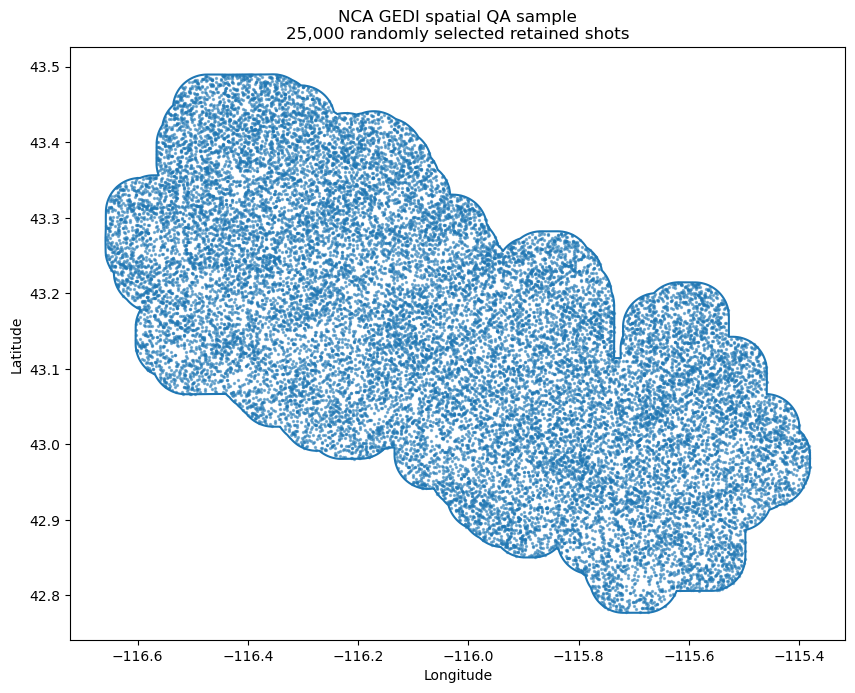

In [13]:
# ------------------------------------------------------------
# 10. Random spatial QA sample
# ------------------------------------------------------------

qa_n = min(
    25_000,
    len(retained_gdf)
)

if qa_n > 0:

    retained_sample = retained_gdf.sample(
        n=qa_n,
        random_state=42
    )

    fig, ax = plt.subplots(figsize=(10, 10))

    aoi_4326.boundary.plot(
        ax=ax,
        linewidth=1.5
    )

    retained_sample.plot(
        ax=ax,
        markersize=2,
        alpha=0.50
    )

    ax.set_title(
        "NCA GEDI spatial QA sample\n"
        f"{qa_n:,} randomly selected retained shots"
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    plt.show()

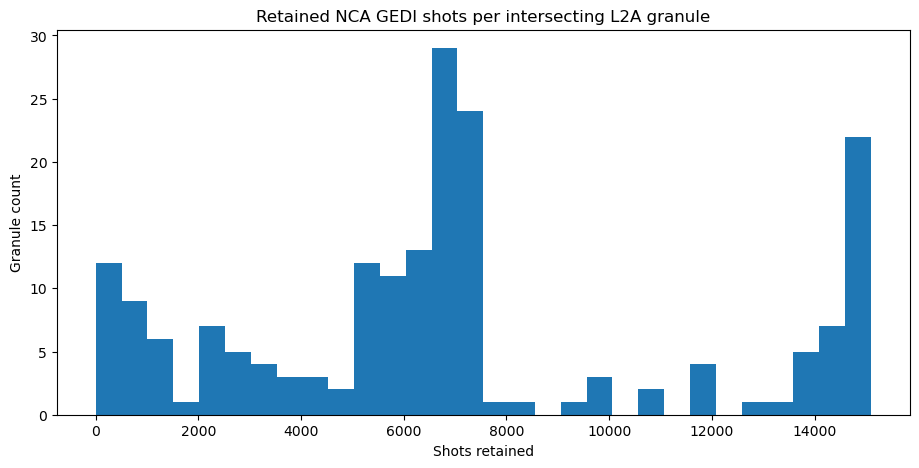

,retained_shots
beam,
BEAM0000,164436
BEAM0001,164846
BEAM0010,166003
BEAM0011,166603
BEAM0101,166316
BEAM0110,166798
BEAM1000,162201
BEAM1011,162575


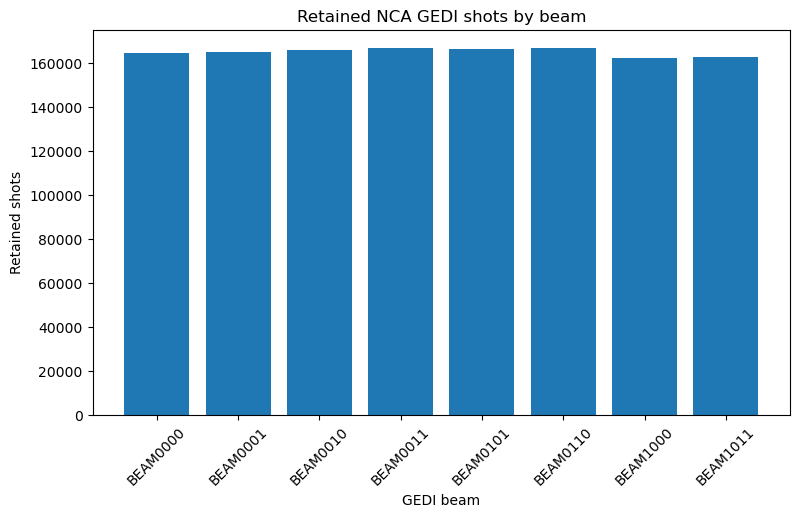

In [14]:
# ------------------------------------------------------------
# 11A. Retained shots per intersecting granule
# ------------------------------------------------------------

granule_plot = (
    granule_spatial_summary.loc[
        granule_spatial_summary["nca_shots"] > 0
    ]
    .sort_values(
        "nca_shots",
        ascending=False
    )
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(
    granule_plot["nca_shots"],
    bins=30
)

ax.set_title(
    "Retained NCA GEDI shots per intersecting L2A granule"
)

ax.set_xlabel("Shots retained")
ax.set_ylabel("Granule count")

plt.show()


# ------------------------------------------------------------
# 11B. Retained shots by beam
# ------------------------------------------------------------

beam_counts = (
    l2a_retained
    .groupby("beam")
    .size()
    .sort_index()
)

display(
    beam_counts
    .rename("retained_shots")
    .to_frame()
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    beam_counts.index,
    beam_counts.values
)

ax.set_title(
    "Retained NCA GEDI shots by beam"
)

ax.set_xlabel("GEDI beam")
ax.set_ylabel("Retained shots")

ax.tick_params(
    axis="x",
    rotation=45
)

plt.show()

In [15]:
# ------------------------------------------------------------
# 13. Repacker configuration
# ------------------------------------------------------------

ROOT = Path(
    r"A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A"
)

RAW_L1B_DIR = ROOT / "raw_h5" / "GEDI01_B"
RAW_L2A_DIR = ROOT / "raw_h5" / "GEDI02_A"

OUT_ROOT = ROOT / "NCA_spatial_subset_h5"
OUT_L1B_DIR = OUT_ROOT / "GEDI01_B"
OUT_L2A_DIR = OUT_ROOT / "GEDI02_A"
MANIFEST_DIR = OUT_ROOT / "manifests"

# Safety switches
WRITE_SUBSETS = True
OVERWRITE_EXISTING = False

# Compression for new analytical HDF5 datasets.
GZIP_LEVEL = 4

print("Raw L1B:", RAW_L1B_DIR)
print("Raw L2A:", RAW_L2A_DIR)
print("Output:", OUT_ROOT)
print()
print("WRITE_SUBSETS =", WRITE_SUBSETS)
print("OVERWRITE_EXISTING =", OVERWRITE_EXISTING)

assert RAW_L1B_DIR.exists()
assert RAW_L2A_DIR.exists()

Raw L1B: A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\raw_h5\GEDI01_B
Raw L2A: A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\raw_h5\GEDI02_A
Output: A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5

WRITE_SUBSETS = True
OVERWRITE_EXISTING = False


In [16]:
# ------------------------------------------------------------
# 14. Canonical retained-shot lookup
# ------------------------------------------------------------

required_columns = {
    "granule_key",
    "beam",
    "shot_number",
    "source_l2a",
}

missing = required_columns - set(l2a_retained.columns)

if missing:
    raise ValueError(
        f"l2a_retained is missing required columns: {missing}"
    )


def selected_shots_for_granule(granule_key):
    """
    Return retained NCA shot numbers organized by beam.
    """
    subset = l2a_retained.loc[
        l2a_retained["granule_key"].eq(granule_key)
    ]

    return {
        beam: group["shot_number"].to_numpy()
        for beam, group in subset.groupby("beam")
    }


intersecting_granules = (
    granule_spatial_summary.loc[
        granule_spatial_summary["nca_shots"] > 0
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    f"Intersecting granules expected for repacking: "
    f"{len(intersecting_granules):,}"
)

print(
    f"Canonical retained shots: "
    f"{len(l2a_retained):,}"
)

Intersecting granules expected for repacking: 189
Canonical retained shots: 1,319,778


In [17]:
# ------------------------------------------------------------
# 15. Generic HDF5 helpers
# ------------------------------------------------------------

def copy_attrs(src_obj, dst_obj):
    """
    Copy HDF5 attributes.
    """
    for key, value in src_obj.attrs.items():
        dst_obj.attrs[key] = value


def compression_kwargs(data):
    """
    Apply gzip/shuffle to ordinary numeric arrays.

    Fall back to no compression for scalars, very small arrays,
    strings, or unusual HDF5 datatypes.
    """
    arr = np.asarray(data)

    if arr.ndim == 0 or arr.size <= 1:
        return {}

    if arr.dtype.kind in {"O", "U", "S"}:
        return {}

    return {
        "compression": "gzip",
        "compression_opts": GZIP_LEVEL,
        "shuffle": True,
    }


def write_dataset(dst_group, name, data, src_ds):
    """
    Write a dataset and preserve its source attributes.
    """
    kwargs = compression_kwargs(data)

    try:
        dst_ds = dst_group.create_dataset(
            name,
            data=data,
            **kwargs
        )

    except (TypeError, ValueError):
        # Conservative fallback for unusual dataset types.
        dst_ds = dst_group.create_dataset(
            name,
            data=data
        )

    copy_attrs(src_ds, dst_ds)

    return dst_ds


def copy_root_nonbeam_items(src_h5, dst_h5):
    """
    Copy root metadata and non-BEAM groups/datasets intact.
    """
    copy_attrs(src_h5, dst_h5)

    for name, obj in src_h5.items():

        if name.startswith("BEAM"):
            continue

        src_h5.copy(
            obj,
            dst_h5,
            name=name
        )


def copy_or_subset_beam_group(
    src_group,
    dst_group,
    retained_idx,
    n_shots,
    overrides=None,
    skip_paths=None,
):
    """
    Recursively copy a GEDI beam.

    Dataset rule:
      first dimension == n_shots  -> subset rows
      otherwise                   -> copy intact

    overrides:
      dict of relative path -> replacement array

    skip_paths:
      datasets that are handled separately, e.g. rxwaveform
    """
    overrides = overrides or {}
    skip_paths = skip_paths or set()

    copy_attrs(src_group, dst_group)

    def recurse(src_g, dst_g, prefix=""):

        for name, obj in src_g.items():

            relpath = (
                f"{prefix}/{name}"
                if prefix
                else name
            )

            if relpath in skip_paths:
                continue

            if isinstance(obj, h5py.Group):

                new_group = dst_g.create_group(name)

                copy_attrs(
                    obj,
                    new_group
                )

                recurse(
                    obj,
                    new_group,
                    relpath
                )

            elif isinstance(obj, h5py.Dataset):

                if relpath in overrides:

                    data = overrides[relpath]

                elif (
                    obj.ndim >= 1
                    and obj.shape[0] == n_shots
                ):

                    data = obj[retained_idx, ...]

                else:

                    data = obj[...]

                write_dataset(
                    dst_g,
                    name,
                    data,
                    obj
                )

    recurse(
        src_group,
        dst_group
    )

In [18]:
# ------------------------------------------------------------
# 16. Rebuild concatenated L1B waveform arrays
# ------------------------------------------------------------

def rebuild_waveform(
    src_beam,
    retained_idx,
    prefix
):
    """
    Rebuild rxwaveform or txwaveform for selected shots.

    GEDI sample_start_index is treated as 1-based.

    Returns None if that waveform family does not exist.
    """

    waveform_name = f"{prefix}waveform"
    start_name = f"{prefix}_sample_start_index"
    count_name = f"{prefix}_sample_count"

    required = [
        waveform_name,
        start_name,
        count_name,
    ]

    if not all(
        name in src_beam
        for name in required
    ):
        return None

    waveform_ds = src_beam[waveform_name]

    original_start_all = (
        src_beam[start_name][:]
    )

    count_all = (
        src_beam[count_name][:]
    )

    original_start = (
        original_start_all[retained_idx]
    )

    counts = (
        count_all[retained_idx]
    )

    # Convert GEDI's 1-based indexing to Python 0-based indexing.
    start0 = (
        original_start.astype(np.int64)
        - 1
    )

    counts64 = (
        counts.astype(np.int64)
    )

    if np.any(start0 < 0):
        raise ValueError(
            f"{src_beam.name}: "
            f"invalid {prefix} start index"
        )

    ends = start0 + counts64

    if len(ends):

        if np.max(ends) > len(waveform_ds):
            raise ValueError(
                f"{src_beam.name}: "
                f"{prefix} waveform segment "
                "extends beyond waveform vector."
            )

    # Extract retained waveform slices.
    segments = [
        waveform_ds[start:end]
        for start, end in zip(
            start0,
            ends
        )
        if end > start
    ]

    if segments:

        new_waveform = np.concatenate(
            segments
        )

    else:

        new_waveform = np.empty(
            0,
            dtype=waveform_ds.dtype
        )

    # New 1-based start indices.
    new_start = np.empty(
        len(counts64),
        dtype=original_start_all.dtype
    )

    if len(new_start):

        cumulative = np.concatenate(
            (
                [0],
                np.cumsum(
                    counts64[:-1],
                    dtype=np.int64
                )
            )
        )

        new_start[:] = cumulative + 1

    return {
        "waveform": new_waveform,
        "original_start": original_start,
        "new_start": new_start,
        "counts": counts,
        "waveform_source": waveform_ds,
    }

In [19]:
# ------------------------------------------------------------
# 17. Write one NCA-only L2A granule
# ------------------------------------------------------------

def write_l2a_subset(
    source_path,
    destination_path,
    selected_shots
):
    """
    Write spatially retained L2A shots only.
    """

    partial_path = (
        destination_path.with_suffix(
            ".partial.h5"
        )
    )

    if partial_path.exists():
        partial_path.unlink()

    with (
        h5py.File(source_path, "r") as src,
        h5py.File(partial_path, "w") as dst
    ):

        copy_root_nonbeam_items(
            src,
            dst
        )

        for beam, target_shots in selected_shots.items():

            if beam not in src:
                raise KeyError(
                    f"{source_path.name}: "
                    f"{beam} missing."
                )

            src_beam = src[beam]

            all_shots = (
                src_beam["shot_number"][:]
            )

            retained_idx = np.flatnonzero(
                np.isin(
                    all_shots,
                    target_shots
                )
            )

            if len(retained_idx) != len(target_shots):
                raise ValueError(
                    f"{source_path.name} {beam}: "
                    f"expected {len(target_shots):,} "
                    f"shots, matched "
                    f"{len(retained_idx):,}."
                )

            dst_beam = dst.create_group(
                beam
            )

            copy_or_subset_beam_group(
                src_beam,
                dst_beam,
                retained_idx,
                n_shots=len(all_shots),
            )

    return partial_path

In [20]:
# ------------------------------------------------------------
# 18. Write one NCA-only L1B granule
# ------------------------------------------------------------

def write_l1b_subset(
    source_path,
    destination_path,
    selected_shots
):
    """
    Subset shot-oriented L1B datasets and rebuild
    concatenated RX/TX waveform arrays.
    """

    partial_path = (
        destination_path.with_suffix(
            ".partial.h5"
        )
    )

    if partial_path.exists():
        partial_path.unlink()

    manifest_parts = []

    with (
        h5py.File(source_path, "r") as src,
        h5py.File(partial_path, "w") as dst
    ):

        copy_root_nonbeam_items(
            src,
            dst
        )

        for beam, target_shots in selected_shots.items():

            if beam not in src:
                raise KeyError(
                    f"{source_path.name}: "
                    f"{beam} missing."
                )

            src_beam = src[beam]

            all_shots = (
                src_beam["shot_number"][:]
            )

            retained_idx = np.flatnonzero(
                np.isin(
                    all_shots,
                    target_shots
                )
            )

            if len(retained_idx) != len(target_shots):
                raise ValueError(
                    f"{source_path.name} {beam}: "
                    f"L2A selected "
                    f"{len(target_shots):,} shots, "
                    f"L1B matched "
                    f"{len(retained_idx):,}."
                )

            matched_shots = (
                all_shots[retained_idx]
            )

            # Exact set correspondence check.
            if (
                set(matched_shots.tolist())
                != set(target_shots.tolist())
            ):
                raise ValueError(
                    f"{source_path.name} {beam}: "
                    "shot-number mismatch."
                )

            rx = rebuild_waveform(
                src_beam,
                retained_idx,
                "rx"
            )

            tx = rebuild_waveform(
                src_beam,
                retained_idx,
                "tx"
            )

            overrides = {}
            skip_paths = set()

            if rx is not None:

                overrides[
                    "rx_sample_start_index"
                ] = rx["new_start"]

                overrides[
                    "rx_sample_count"
                ] = rx["counts"]

                skip_paths.add(
                    "rxwaveform"
                )

            if tx is not None:

                overrides[
                    "tx_sample_start_index"
                ] = tx["new_start"]

                overrides[
                    "tx_sample_count"
                ] = tx["counts"]

                skip_paths.add(
                    "txwaveform"
                )

            dst_beam = dst.create_group(
                beam
            )

            copy_or_subset_beam_group(
                src_beam,
                dst_beam,
                retained_idx,
                n_shots=len(all_shots),
                overrides=overrides,
                skip_paths=skip_paths,
            )

            # Write reconstructed waveform arrays.
            if rx is not None:

                write_dataset(
                    dst_beam,
                    "rxwaveform",
                    rx["waveform"],
                    rx["waveform_source"]
                )

            if tx is not None:

                write_dataset(
                    dst_beam,
                    "txwaveform",
                    tx["waveform"],
                    tx["waveform_source"]
                )

            # Shot-level provenance.
            manifest = pd.DataFrame(
                {
                    "beam": beam,
                    "shot_number": matched_shots,
                }
            )

            if rx is not None:

                manifest[
                    "original_rx_sample_start_index"
                ] = rx["original_start"]

                manifest[
                    "rx_sample_count"
                ] = rx["counts"]

                manifest[
                    "new_rx_sample_start_index"
                ] = rx["new_start"]

            if tx is not None:

                manifest[
                    "original_tx_sample_start_index"
                ] = tx["original_start"]

                manifest[
                    "tx_sample_count"
                ] = tx["counts"]

                manifest[
                    "new_tx_sample_start_index"
                ] = tx["new_start"]

            manifest_parts.append(
                manifest
            )

    full_manifest = pd.concat(
        manifest_parts,
        ignore_index=True
    )

    return (
        partial_path,
        full_manifest
    )

In [21]:
# ------------------------------------------------------------
# 19. Validate rewritten L2A / L1B pair
# ------------------------------------------------------------

def validate_subset_pair(
    l2a_path,
    l1b_path,
    selected_shots
):
    """
    Validate:
      * shot-number equivalence
      * shot counts
      * RX/TX start/count dimensions
      * contiguous rebuilt waveform indexing
      * final waveform endpoint
    """

    rows = []

    with (
        h5py.File(l2a_path, "r") as l2a,
        h5py.File(l1b_path, "r") as l1b
    ):

        for beam, target in selected_shots.items():

            if beam not in l2a:
                raise ValueError(
                    f"L2A output missing {beam}"
                )

            if beam not in l1b:
                raise ValueError(
                    f"L1B output missing {beam}"
                )

            l2a_shots = (
                l2a[f"{beam}/shot_number"][:]
            )

            l1b_shots = (
                l1b[f"{beam}/shot_number"][:]
            )

            target_set = set(
                target.tolist()
            )

            if (
                len(l2a_shots) != len(target)
                or set(l2a_shots.tolist())
                != target_set
            ):
                raise ValueError(
                    f"{beam}: L2A shot validation failed."
                )

            if (
                len(l1b_shots) != len(target)
                or set(l1b_shots.tolist())
                != target_set
            ):
                raise ValueError(
                    f"{beam}: L1B shot validation failed."
                )

            row = {
                "beam": beam,
                "shots": len(target),
                "l2a_ok": True,
                "l1b_ok": True,
                "rx_ok": None,
                "tx_ok": None,
            }

            for prefix in ("rx", "tx"):

                waveform_name = (
                    f"{prefix}waveform"
                )

                start_name = (
                    f"{prefix}_sample_start_index"
                )

                count_name = (
                    f"{prefix}_sample_count"
                )

                if not all(
                    name in l1b[beam]
                    for name in (
                        waveform_name,
                        start_name,
                        count_name,
                    )
                ):
                    continue

                waveform_len = len(
                    l1b[
                        f"{beam}/{waveform_name}"
                    ]
                )

                starts = (
                    l1b[
                        f"{beam}/{start_name}"
                    ][:]
                    .astype(np.int64)
                )

                counts = (
                    l1b[
                        f"{beam}/{count_name}"
                    ][:]
                    .astype(np.int64)
                )

                if (
                    len(starts) != len(target)
                    or len(counts) != len(target)
                ):
                    raise ValueError(
                        f"{beam}: {prefix} "
                        "index/count length mismatch."
                    )

                if len(counts):

                    expected_starts = (
                        np.concatenate(
                            (
                                [0],
                                np.cumsum(
                                    counts[:-1],
                                    dtype=np.int64
                                )
                            )
                        )
                        + 1
                    )

                else:

                    expected_starts = np.array(
                        [],
                        dtype=np.int64
                    )

                starts_ok = np.array_equal(
                    starts,
                    expected_starts
                )

                if len(starts):

                    expected_end = int(
                        starts[-1]
                        - 1
                        + counts[-1]
                    )

                else:

                    expected_end = 0

                endpoint_ok = (
                    expected_end
                    == waveform_len
                )

                waveform_ok = (
                    starts_ok
                    and endpoint_ok
                )

                if not waveform_ok:
                    raise ValueError(
                        f"{beam}: rebuilt "
                        f"{prefix} waveform failed QA."
                    )

                row[f"{prefix}_ok"] = True

            rows.append(row)

    return pd.DataFrame(rows)

In [22]:
# ------------------------------------------------------------
# 20. Production repacking loop
# ------------------------------------------------------------

production_rows = []

if not WRITE_SUBSETS:

    print(
        "DRY RUN ONLY.\n"
        "Set WRITE_SUBSETS = True in Cell 13 "
        "to write NCA subset HDF5 files."
    )

else:

    OUT_L1B_DIR.mkdir(
        parents=True,
        exist_ok=True
    )

    OUT_L2A_DIR.mkdir(
        parents=True,
        exist_ok=True
    )

    MANIFEST_DIR.mkdir(
        parents=True,
        exist_ok=True
    )

    for i, row in intersecting_granules.iterrows():

        key = row["granule_key"]

        print(
            f"\n[{i+1}/{len(intersecting_granules)}] "
            f"{key}"
        )

        selected = (
            selected_shots_for_granule(
                key
            )
        )

        # Find source L2A from the spatial-summary record.
        source_l2a_name = row["source_l2a"]

        l2a_source = (
            RAW_L2A_DIR
            / source_l2a_name
        )

        # Existing diagnostic lookup from Cell 6.
        l1b_source = l1b_lookup.get(
            key
        )

        result = {
            "granule_key": key,
            "nca_shots": int(row["nca_shots"]),
            "source_l2a": l2a_source.name,
            "source_l1b": (
                l1b_source.name
                if l1b_source is not None
                else None
            ),
            "status": None,
            "error": None,
        }

        if l1b_source is None:

            print(
                "  FAILED: matching L1B not found"
            )

            result["status"] = (
                "FAILED_NO_L1B"
            )

            production_rows.append(
                result
            )

            continue

        l2a_destination = (
            OUT_L2A_DIR
            / l2a_source.name
        )

        l1b_destination = (
            OUT_L1B_DIR
            / l1b_source.name
        )

        if (
            not OVERWRITE_EXISTING
            and (
                l2a_destination.exists()
                or l1b_destination.exists()
            )
        ):

            print(
                "  SKIP: completed output exists"
            )

            result["status"] = (
                "SKIPPED_EXISTS"
            )

            production_rows.append(
                result
            )

            continue

        try:

            if OVERWRITE_EXISTING:

                for path in (
                    l2a_destination,
                    l1b_destination,
                ):

                    if path.exists():
                        path.unlink()

            # -----------------------------------------
            # Write temporary L2A
            # -----------------------------------------

            l2a_partial = write_l2a_subset(
                l2a_source,
                l2a_destination,
                selected
            )

            # -----------------------------------------
            # Write temporary L1B
            # -----------------------------------------

            (
                l1b_partial,
                shot_manifest
            ) = write_l1b_subset(
                l1b_source,
                l1b_destination,
                selected
            )

            # -----------------------------------------
            # Validate before promotion
            # -----------------------------------------

            validation = validate_subset_pair(
                l2a_partial,
                l1b_partial,
                selected
            )

            # -----------------------------------------
            # Promote .partial -> final .h5
            # -----------------------------------------

            l2a_partial.replace(
                l2a_destination
            )

            l1b_partial.replace(
                l1b_destination
            )

            # -----------------------------------------
            # Manifest
            # -----------------------------------------

            shot_manifest.insert(
                0,
                "granule_key",
                key
            )

            shot_manifest.insert(
                1,
                "source_l2a",
                l2a_source.name
            )

            shot_manifest.insert(
                2,
                "source_l1b",
                l1b_source.name
            )

            manifest_path = (
                MANIFEST_DIR
                / f"{key}_shot_manifest.csv.gz"
            )

            shot_manifest.to_csv(
                manifest_path,
                index=False,
                compression="gzip"
            )

            validation_path = (
                MANIFEST_DIR
                / f"{key}_validation.csv"
            )

            validation.to_csv(
                validation_path,
                index=False
            )

            # -----------------------------------------
            # Actual storage comparison
            # -----------------------------------------

            raw_bytes = (
                l2a_source.stat().st_size
                + l1b_source.stat().st_size
            )

            subset_bytes = (
                l2a_destination.stat().st_size
                + l1b_destination.stat().st_size
            )

            storage_retained = (
                100
                * subset_bytes
                / raw_bytes
            )

            result.update(
                {
                    "status": "VALIDATED",
                    "l2a_raw_gib":
                        l2a_source.stat().st_size
                        / 1024**3,
                    "l1b_raw_gib":
                        l1b_source.stat().st_size
                        / 1024**3,
                    "l2a_subset_gib":
                        l2a_destination.stat().st_size
                        / 1024**3,
                    "l1b_subset_gib":
                        l1b_destination.stat().st_size
                        / 1024**3,
                    "storage_retained_percent":
                        storage_retained,
                }
            )

            print(
                f"  VALIDATED | "
                f"{len(shot_manifest):,} shots | "
                f"{storage_retained:.3f}% "
                "of paired file volume retained"
            )

        except Exception as exc:

            result["status"] = "FAILED"
            result["error"] = str(exc)

            print(
                f"  FAILED: {exc}"
            )

            # Only remove incomplete products.
            for partial in (
                l2a_destination.with_suffix(
                    ".partial.h5"
                ),
                l1b_destination.with_suffix(
                    ".partial.h5"
                ),
            ):

                if partial.exists():
                    partial.unlink()

        production_rows.append(
            result
        )


production_summary = pd.DataFrame(
    production_rows
)

if len(production_summary):

    display(
        production_summary
    )

    OUT_ROOT.mkdir(
        parents=True,
        exist_ok=True
    )

    production_summary.to_csv(
        OUT_ROOT
        / "NCA_GEDI_repacking_audit.csv",
        index=False
    )


[1/189] O02061_02_T00905_02
  VALIDATED | 6,886 shots | 0.923% of paired file volume retained

[2/189] O02168_02_T05021_02
  VALIDATED | 5,898 shots | 0.803% of paired file volume retained

[3/189] O02202_03_T00174_02
  VALIDATED | 9,371 shots | 0.844% of paired file volume retained

[4/189] O02275_02_T03292_02
  VALIDATED | 6,314 shots | 0.924% of paired file volume retained

[5/189] O02309_03_T01444_02
  VALIDATED | 14,644 shots | 1.191% of paired file volume retained

[6/189] O02382_02_T01869_02
  VALIDATED | 7,170 shots | 0.929% of paired file volume retained

[7/189] O02416_03_T03984_02
  VALIDATED | 14,145 shots | 0.894% of paired file volume retained

[8/189] O02489_02_T00140_02
  VALIDATED | 5,474 shots | 0.969% of paired file volume retained

[9/189] O02657_02_T05679_02
  VALIDATED | 2,428 shots | 0.401% of paired file volume retained

[10/189] O02718_02_T01058_02
  VALIDATED | 6,192 shots | 0.639% of paired file volume retained

[11/189] O02752_03_T01597_02
  VALIDATED | 14,

,granule_key,nca_shots,source_l2a,source_l1b,status,error,l2a_raw_gib,l1b_raw_gib,l2a_subset_gib,l1b_subset_gib,storage_retained_percent
0,O02061_02_T00905_02,6886,GEDI02_A_2019114135421_O02061_02_T00905_02_003...,GEDI01_B_2019114135421_O02061_02_T00905_02_005...,VALIDATED,None,1.697969,2.545184,0.021274,0.017910,0.923475
1,O02168_02_T05021_02,5898,GEDI02_A_2019121111147_O02168_02_T05021_02_003...,GEDI01_B_2019121111147_O02168_02_T05021_02_005...,VALIDATED,None,1.783429,2.499899,0.019337,0.015075,0.803392
2,O02202_03_T00174_02,9371,GEDI02_A_2019123154305_O02202_03_T00174_02_003...,GEDI01_B_2019123154305_O02202_03_T00174_02_005...,VALIDATED,None,2.144003,3.480744,0.024166,0.023308,0.844011
3,O02275_02_T03292_02,6314,GEDI02_A_2019128082902_O02275_02_T03292_02_003...,GEDI01_B_2019128082902_O02275_02_T03292_02_005...,VALIDATED,None,1.768987,2.187953,0.020386,0.016195,0.924484
4,O02309_03_T01444_02,14644,GEDI02_A_2019130130016_O02309_03_T01444_02_003...,GEDI01_B_2019130130016_O02309_03_T01444_02_005...,VALIDATED,None,2.247606,3.477498,0.032546,0.035644,1.191063
...,...,...,...,...,...,...,...,...,...,...,...
184,O33457_02_T09611_02,7010,GEDI02_A_2024313040023_O33457_02_T09611_02_004...,GEDI01_B_2024313040023_O33457_02_T09611_02_006...,VALIDATED,None,0.881679,2.083325,0.013969,0.016422,1.024980
185,O33549_02_T09948_02,4897,GEDI02_A_2024319021500_O33549_02_T09948_02_004...,GEDI01_B_2024319021500_O33549_02_T09948_02_006...,VALIDATED,None,1.300235,1.924797,0.013377,0.012291,0.795890
186,O33610_02_T07561_02,7205,GEDI02_A_2024323003853_O33610_02_T07561_02_004...,GEDI01_B_2024323003853_O33610_02_T07561_02_006...,VALIDATED,None,1.238486,1.975804,0.015213,0.016990,1.001873
187,O33732_02_T01211_02,5108,GEDI02_A_2024330212634_O33732_02_T01211_02_004...,GEDI01_B_2024330212634_O33732_02_T01211_02_006...,VALIDATED,None,1.317717,2.155891,0.019253,0.013522,0.943545


In [23]:
# ------------------------------------------------------------
# 21. Final archive-readiness audit
# ------------------------------------------------------------

if not WRITE_SUBSETS:

    print(
        "No production files were written."
    )

else:

    expected_pairs = len(
        intersecting_granules
    )

    validated = int(
        production_summary[
            "status"
        ].eq("VALIDATED").sum()
    )

    failed = int(
        production_summary[
            "status"
        ]
        .astype(str)
        .str.startswith("FAILED")
        .sum()
    )

    skipped = int(
        production_summary[
            "status"
        ].eq("SKIPPED_EXISTS").sum()
    )

    print(
        "NCA GEDI REPACKING AUDIT"
    )

    print(
        "========================"
    )

    print(
        f"Expected intersecting pairs: "
        f"{expected_pairs:,}"
    )

    print(
        f"Validated this run:          "
        f"{validated:,}"
    )

    print(
        f"Skipped existing:            "
        f"{skipped:,}"
    )

    print(
        f"Failed:                      "
        f"{failed:,}"
    )

    clean_run = (
        validated == expected_pairs
        and failed == 0
        and skipped == 0
    )

    print()
    print(
        "Clean complete run:",
        clean_run
    )

    validated_rows = (
        production_summary.loc[
            production_summary[
                "status"
            ].eq("VALIDATED")
        ]
        .copy()
    )

    if len(validated_rows):

        raw_gib = (
            validated_rows[
                "l1b_raw_gib"
            ].sum()
            +
            validated_rows[
                "l2a_raw_gib"
            ].sum()
        )

        subset_gib = (
            validated_rows[
                "l1b_subset_gib"
            ].sum()
            +
            validated_rows[
                "l2a_subset_gib"
            ].sum()
        )

        retained_pct = (
            100
            * subset_gib
            / raw_gib
        )

        print()
        print(
            f"Raw volume represented: "
            f"{raw_gib:,.2f} GiB"
        )

        print(
            f"NCA subset volume:      "
            f"{subset_gib:,.2f} GiB"
        )

        print(
            f"Storage retained:       "
            f"{retained_pct:.3f}%"
        )

        print(
            f"Storage eliminated:     "
            f"{100-retained_pct:.3f}%"
        )

NCA GEDI REPACKING AUDIT
Expected intersecting pairs: 189
Validated this run:          189
Skipped existing:            0
Failed:                      0

Clean complete run: True

Raw volume represented: 833.77 GiB
NCA subset volume:      6.91 GiB
Storage retained:       0.829%
Storage eliminated:     99.171%


In [24]:
# ------------------------------------------------------------
# 22. Scientific-equivalence validation
# ------------------------------------------------------------

# Number of retained shots to test across the collection
N_QA_SHOTS = 100

RANDOM_SEED = 42


# ------------------------------------------------------------
# Build a stratified sample across granules and beams
# ------------------------------------------------------------

qa_source = (
    l2a_retained[
        [
            "granule_key",
            "beam",
            "shot_number",
            "source_l2a",
        ]
    ]
    .drop_duplicates()
    .copy()
)

# Sample approximately evenly across beam × granule combinations
groups = list(
    qa_source.groupby(
        ["granule_key", "beam"],
        sort=False
    )
)

rng = np.random.default_rng(
    RANDOM_SEED
)

sampled_rows = []

# First give as many groups as possible one observation
group_order = rng.permutation(
    len(groups)
)

for group_i in group_order:

    if len(sampled_rows) >= N_QA_SHOTS:
        break

    _, group = groups[group_i]

    row = group.sample(
        n=1,
        random_state=int(
            rng.integers(
                0,
                2**31 - 1
            )
        )
    )

    sampled_rows.append(
        row
    )


# If fewer than N_QA_SHOTS were obtained,
# fill from the remaining retained-shot population.
if sampled_rows:

    qa_sample = pd.concat(
        sampled_rows,
        ignore_index=True
    )

else:

    qa_sample = pd.DataFrame(
        columns=qa_source.columns
    )


if len(qa_sample) < N_QA_SHOTS:

    already_selected = set(
        zip(
            qa_sample["granule_key"],
            qa_sample["beam"],
            qa_sample["shot_number"],
        )
    )

    remaining = qa_source.loc[
        ~qa_source.apply(
            lambda r: (
                r["granule_key"],
                r["beam"],
                r["shot_number"]
            )
            in already_selected,
            axis=1
        )
    ]

    n_needed = min(
        N_QA_SHOTS - len(qa_sample),
        len(remaining)
    )

    if n_needed > 0:

        fill = remaining.sample(
            n=n_needed,
            random_state=RANDOM_SEED
        )

        qa_sample = pd.concat(
            [
                qa_sample,
                fill
            ],
            ignore_index=True
        )


print(
    f"Scientific-equivalence QA sample: "
    f"{len(qa_sample):,} shots"
)

display(
    qa_sample.head(20)
)


# ------------------------------------------------------------
# Helper: extract one waveform from an L1B beam
# ------------------------------------------------------------

def extract_waveform_for_shot(
    beam_group,
    shot_index,
    prefix
):
    """
    Extract rxwaveform or txwaveform for one shot.

    Uses GEDI 1-based sample_start_index.
    """

    waveform_name = f"{prefix}waveform"
    start_name = f"{prefix}_sample_start_index"
    count_name = f"{prefix}_sample_count"

    required = [
        waveform_name,
        start_name,
        count_name,
    ]

    if not all(
        name in beam_group
        for name in required
    ):
        return None, None

    start = int(
        beam_group[start_name][shot_index]
    )

    count = int(
        beam_group[count_name][shot_index]
    )

    start0 = start - 1

    waveform = (
        beam_group[waveform_name][
            start0:start0 + count
        ]
    )

    return waveform, count


# ------------------------------------------------------------
# Helper: compare optional shot-oriented datasets
# ------------------------------------------------------------

def compare_optional_dataset(
    raw_beam,
    subset_beam,
    dataset_path,
    raw_idx,
    subset_idx
):
    """
    Exact comparison for a shot-oriented dataset if it exists
    in both raw and subset files.

    Returns:
        True  -> exists and matches
        False -> exists but differs
        None  -> absent from one or both files
    """

    if (
        dataset_path not in raw_beam
        or dataset_path not in subset_beam
    ):
        return None

    raw_ds = raw_beam[dataset_path]
    subset_ds = subset_beam[dataset_path]

    raw_value = raw_ds[raw_idx]
    subset_value = subset_ds[subset_idx]

    try:
        return np.array_equal(
            np.asarray(raw_value),
            np.asarray(subset_value),
            equal_nan=True
        )

    except TypeError:
        return np.array_equal(
            np.asarray(raw_value),
            np.asarray(subset_value)
        )


# ------------------------------------------------------------
# Fields worth explicitly auditing
# ------------------------------------------------------------

l1b_metadata_fields = [
    "delta_time",
    "geolocation/latitude_bin0",
    "geolocation/longitude_bin0",
    "geolocation/elevation_bin0",
    "geolocation/latitude_lastbin",
    "geolocation/longitude_lastbin",
    "geolocation/elevation_lastbin",
]

l2a_metadata_fields = [
    "delta_time",
    "lat_lowestmode",
    "lon_lowestmode",
    "elev_lowestmode",
    "lat_highestreturn",
    "lon_highestreturn",
    "elev_highestreturn",
]


# ------------------------------------------------------------
# Run raw-vs-subset comparisons
# ------------------------------------------------------------

qa_results = []


for i, row in qa_sample.iterrows():

    key = row["granule_key"]
    beam = row["beam"]
    shot_number = row["shot_number"]

    raw_l2a_path = (
        RAW_L2A_DIR
        / row["source_l2a"]
    )

    raw_l1b_path = (
        l1b_lookup[key]
    )

    subset_l2a_path = (
        OUT_L2A_DIR
        / raw_l2a_path.name
    )

    subset_l1b_path = (
        OUT_L1B_DIR
        / raw_l1b_path.name
    )

    result = {
        "granule_key": key,
        "beam": beam,
        "shot_number": shot_number,
        "raw_l1b": raw_l1b_path.name,
        "subset_l1b": subset_l1b_path.name,
        "raw_l2a": raw_l2a_path.name,
        "subset_l2a": subset_l2a_path.name,
        "shot_number_ok": False,
        "rx_count_ok": None,
        "rx_waveform_ok": None,
        "tx_count_ok": None,
        "tx_waveform_ok": None,
        "l1b_metadata_ok": None,
        "l2a_metadata_ok": None,
        "all_ok": False,
        "error": None,
    }


    try:

        if not subset_l1b_path.exists():
            raise FileNotFoundError(
                f"Subset L1B missing: "
                f"{subset_l1b_path}"
            )

        if not subset_l2a_path.exists():
            raise FileNotFoundError(
                f"Subset L2A missing: "
                f"{subset_l2a_path}"
            )


        # ----------------------------------------------------
        # L1B comparison
        # ----------------------------------------------------

        with (
            h5py.File(
                raw_l1b_path,
                "r"
            ) as raw_l1b,
            h5py.File(
                subset_l1b_path,
                "r"
            ) as subset_l1b,
        ):

            raw_beam = raw_l1b[beam]
            subset_beam = subset_l1b[beam]

            raw_shots = (
                raw_beam["shot_number"][:]
            )

            subset_shots = (
                subset_beam["shot_number"][:]
            )

            raw_match = np.flatnonzero(
                raw_shots == shot_number
            )

            subset_match = np.flatnonzero(
                subset_shots == shot_number
            )

            if len(raw_match) != 1:
                raise ValueError(
                    f"Expected exactly one raw L1B "
                    f"match; found {len(raw_match)}"
                )

            if len(subset_match) != 1:
                raise ValueError(
                    f"Expected exactly one subset L1B "
                    f"match; found {len(subset_match)}"
                )

            raw_idx = int(
                raw_match[0]
            )

            subset_idx = int(
                subset_match[0]
            )

            result["shot_number_ok"] = (
                raw_shots[raw_idx]
                == subset_shots[subset_idx]
                == shot_number
            )


            # RX waveform
            raw_rx, raw_rx_count = (
                extract_waveform_for_shot(
                    raw_beam,
                    raw_idx,
                    "rx"
                )
            )

            subset_rx, subset_rx_count = (
                extract_waveform_for_shot(
                    subset_beam,
                    subset_idx,
                    "rx"
                )
            )

            if (
                raw_rx is not None
                and subset_rx is not None
            ):

                result["rx_count_ok"] = (
                    raw_rx_count
                    == subset_rx_count
                )

                result["rx_waveform_ok"] = (
                    np.array_equal(
                        raw_rx,
                        subset_rx,
                        equal_nan=True
                    )
                )


            # TX waveform
            raw_tx, raw_tx_count = (
                extract_waveform_for_shot(
                    raw_beam,
                    raw_idx,
                    "tx"
                )
            )

            subset_tx, subset_tx_count = (
                extract_waveform_for_shot(
                    subset_beam,
                    subset_idx,
                    "tx"
                )
            )

            if (
                raw_tx is not None
                and subset_tx is not None
            ):

                result["tx_count_ok"] = (
                    raw_tx_count
                    == subset_tx_count
                )

                result["tx_waveform_ok"] = (
                    np.array_equal(
                        raw_tx,
                        subset_tx,
                        equal_nan=True
                    )
                )


            # Explicit L1B metadata audit
            l1b_checks = []

            for field in l1b_metadata_fields:

                check = compare_optional_dataset(
                    raw_beam,
                    subset_beam,
                    field,
                    raw_idx,
                    subset_idx
                )

                if check is not None:
                    l1b_checks.append(
                        check
                    )

            result["l1b_metadata_ok"] = (
                all(l1b_checks)
                if l1b_checks
                else None
            )


        # ----------------------------------------------------
        # L2A comparison
        # ----------------------------------------------------

        with (
            h5py.File(
                raw_l2a_path,
                "r"
            ) as raw_l2a,
            h5py.File(
                subset_l2a_path,
                "r"
            ) as subset_l2a,
        ):

            raw_beam = raw_l2a[beam]
            subset_beam = subset_l2a[beam]

            raw_shots = (
                raw_beam["shot_number"][:]
            )

            subset_shots = (
                subset_beam["shot_number"][:]
            )

            raw_match = np.flatnonzero(
                raw_shots == shot_number
            )

            subset_match = np.flatnonzero(
                subset_shots == shot_number
            )

            if len(raw_match) != 1:
                raise ValueError(
                    f"Expected exactly one raw L2A "
                    f"match; found {len(raw_match)}"
                )

            if len(subset_match) != 1:
                raise ValueError(
                    f"Expected exactly one subset L2A "
                    f"match; found {len(subset_match)}"
                )

            raw_idx = int(
                raw_match[0]
            )

            subset_idx = int(
                subset_match[0]
            )

            l2a_checks = []

            for field in l2a_metadata_fields:

                check = compare_optional_dataset(
                    raw_beam,
                    subset_beam,
                    field,
                    raw_idx,
                    subset_idx
                )

                if check is not None:
                    l2a_checks.append(
                        check
                    )

            result["l2a_metadata_ok"] = (
                all(l2a_checks)
                if l2a_checks
                else None
            )


        # ----------------------------------------------------
        # Overall result
        # ----------------------------------------------------

        required_checks = [
            result["shot_number_ok"],
        ]

        for field in [
            "rx_count_ok",
            "rx_waveform_ok",
            "tx_count_ok",
            "tx_waveform_ok",
            "l1b_metadata_ok",
            "l2a_metadata_ok",
        ]:

            if result[field] is not None:
                required_checks.append(
                    result[field]
                )

        result["all_ok"] = (
            all(required_checks)
        )


    except Exception as exc:

        result["error"] = str(exc)


    qa_results.append(
        result
    )


scientific_qa = pd.DataFrame(
    qa_results
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

display(
    scientific_qa
)

n_pass = int(
    scientific_qa["all_ok"].sum()
)

n_fail = len(scientific_qa) - n_pass

print()
print(
    "SCIENTIFIC EQUIVALENCE QA"
)

print(
    "========================="
)

print(
    f"Shots tested:   "
    f"{len(scientific_qa):,}"
)

print(
    f"Passed:         "
    f"{n_pass:,}"
)

print(
    f"Failed:         "
    f"{n_fail:,}"
)

print()

print(
    "All sampled shots scientifically equivalent:",
    n_fail == 0
)


if n_fail > 0:

    print(
        "\nFAILED SHOTS"
    )

    display(
        scientific_qa.loc[
            ~scientific_qa["all_ok"]
        ]
    )

Scientific-equivalence QA sample: 100 shots


,granule_key,beam,shot_number,source_l2a
0,O22731_02_T09443_02,BEAM0010,227310200200280032,GEDI02_A_2022351141950_O22731_02_T09443_02_003...
1,O22765_03_T05407_02,BEAM0101,227650500300130723,GEDI02_A_2022353185624_O22765_03_T05407_02_003...
2,O20049_03_T02714_02,BEAM0110,200490600300652003,GEDI02_A_2022178161611_O20049_03_T02714_02_003...
3,O02202_03_T00174_02,BEAM0101,22020500300127512,GEDI02_A_2019123154305_O02202_03_T00174_02_003...
4,O08638_02_T03598_02,BEAM0010,86380200200112753,GEDI02_A_2020173140010_O08638_02_T03598_02_003...
5,O03317_03_T03831_02,BEAM0110,33170600300539815,GEDI02_A_2019195111704_O03317_03_T03831_02_003...
6,O03680_02_T02986_02,BEAM1011,36801100200185694,GEDI02_A_2019218203648_O03680_02_T02986_02_003...
7,O03317_03_T03831_02,BEAM0011,33170300300241997,GEDI02_A_2019195111704_O03317_03_T03831_02_003...
8,O15363_02_T06750_02,BEAM1011,153631100200143902,GEDI02_A_2021241102234_O15363_02_T06750_02_003...
9,O02752_03_T01597_02,BEAM0010,27520200300134441,GEDI02_A_2019159013955_O02752_03_T01597_02_003...


,granule_key,beam,shot_number,raw_l1b,subset_l1b,raw_l2a,subset_l2a,shot_number_ok,rx_count_ok,rx_waveform_ok,tx_count_ok,tx_waveform_ok,l1b_metadata_ok,l2a_metadata_ok,all_ok,error
0,O22731_02_T09443_02,BEAM0010,227310200200280032,GEDI01_B_2022351141950_O22731_02_T09443_02_005...,GEDI01_B_2022351141950_O22731_02_T09443_02_005...,GEDI02_A_2022351141950_O22731_02_T09443_02_003...,GEDI02_A_2022351141950_O22731_02_T09443_02_003...,True,True,True,True,True,True,True,True,None
1,O22765_03_T05407_02,BEAM0101,227650500300130723,GEDI01_B_2022353185624_O22765_03_T05407_02_005...,GEDI01_B_2022353185624_O22765_03_T05407_02_005...,GEDI02_A_2022353185624_O22765_03_T05407_02_003...,GEDI02_A_2022353185624_O22765_03_T05407_02_003...,True,True,True,True,True,True,True,True,None
2,O20049_03_T02714_02,BEAM0110,200490600300652003,GEDI01_B_2022178161611_O20049_03_T02714_02_005...,GEDI01_B_2022178161611_O20049_03_T02714_02_005...,GEDI02_A_2022178161611_O20049_03_T02714_02_003...,GEDI02_A_2022178161611_O20049_03_T02714_02_003...,True,True,True,True,True,True,True,True,None
3,O02202_03_T00174_02,BEAM0101,22020500300127512,GEDI01_B_2019123154305_O02202_03_T00174_02_005...,GEDI01_B_2019123154305_O02202_03_T00174_02_005...,GEDI02_A_2019123154305_O02202_03_T00174_02_003...,GEDI02_A_2019123154305_O02202_03_T00174_02_003...,True,True,True,True,True,True,True,True,None
4,O08638_02_T03598_02,BEAM0010,86380200200112753,GEDI01_B_2020173140010_O08638_02_T03598_02_005...,GEDI01_B_2020173140010_O08638_02_T03598_02_005...,GEDI02_A_2020173140010_O08638_02_T03598_02_003...,GEDI02_A_2020173140010_O08638_02_T03598_02_003...,True,True,True,True,True,True,True,True,None
5,O03317_03_T03831_02,BEAM0110,33170600300539815,GEDI01_B_2019195111704_O03317_03_T03831_02_005...,GEDI01_B_2019195111704_O03317_03_T03831_02_005...,GEDI02_A_2019195111704_O03317_03_T03831_02_003...,GEDI02_A_2019195111704_O03317_03_T03831_02_003...,True,True,True,True,True,True,True,True,None
6,O03680_02_T02986_02,BEAM1011,36801100200185694,GEDI01_B_2019218203648_O03680_02_T02986_02_005...,GEDI01_B_2019218203648_O03680_02_T02986_02_005...,GEDI02_A_2019218203648_O03680_02_T02986_02_003...,GEDI02_A_2019218203648_O03680_02_T02986_02_003...,True,True,True,True,True,True,True,True,None
7,O03317_03_T03831_02,BEAM0011,33170300300241997,GEDI01_B_2019195111704_O03317_03_T03831_02_005...,GEDI01_B_2019195111704_O03317_03_T03831_02_005...,GEDI02_A_2019195111704_O03317_03_T03831_02_003...,GEDI02_A_2019195111704_O03317_03_T03831_02_003...,True,True,True,True,True,True,True,True,None
8,O15363_02_T06750_02,BEAM1011,153631100200143902,GEDI01_B_2021241102234_O15363_02_T06750_02_005...,GEDI01_B_2021241102234_O15363_02_T06750_02_005...,GEDI02_A_2021241102234_O15363_02_T06750_02_003...,GEDI02_A_2021241102234_O15363_02_T06750_02_003...,True,True,True,True,True,True,True,True,None
9,O02752_03_T01597_02,BEAM0010,27520200300134441,GEDI01_B_2019159013955_O02752_03_T01597_02_005...,GEDI01_B_2019159013955_O02752_03_T01597_02_005...,GEDI02_A_2019159013955_O02752_03_T01597_02_003...,GEDI02_A_2019159013955_O02752_03_T01597_02_003...,True,True,True,True,True,True,True,True,None



SCIENTIFIC EQUIVALENCE QA
Shots tested:   100
Passed:         100
Failed:         0

All sampled shots scientifically equivalent: True


In [25]:
# ------------------------------------------------------------
# 23. Save scientific-equivalence QA
# ------------------------------------------------------------

if WRITE_SUBSETS:

    scientific_qa.to_csv(
        OUT_ROOT
        / "NCA_GEDI_scientific_equivalence_QA.csv",
        index=False
    )

    print(
        "Saved:",
        OUT_ROOT
        / "NCA_GEDI_scientific_equivalence_QA.csv"
    )

Saved: A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5\NCA_GEDI_scientific_equivalence_QA.csv
